# Retinal OCT Disease Classification with Vision Transformer (ViT) + Explainability

---


## 🎯 Learning Objectives

This Notebook will examine how to:
1. Load and preprocess a large-scale retinal OCT dataset from HuggingFace Hub
2. Fine-tune a pretrained **Vision Transformer (ViT)** for 4-class medical image classification
3. Evaluate model performance using accuracy, F1, and AUROC
4. Apply **Grad-CAM** and **Attention Rollout** to explain model decisions — and understand why method choice matters for transformer architectures

---

## 🏥 Clinical Background

**Optical Coherence Tomography (OCT)** is a non-invasive retinal imaging modality analogous to ultrasound, but using light rather than sound. It produces cross-sectional B-scan images of the retina with micrometer resolution.

This project classifies OCT B-scans into four categories:

| Class | Full Name | Clinical Significance |
|-------|-----------|----------------------|
| **CNV** | Choroidal Neovascularization | Abnormal blood vessel growth beneath retina; wet AMD |
| **DME** | Diabetic Macular Edema | Fluid accumulation from diabetic retinopathy |
| **DRUSEN** | Drusen deposits | Early-stage dry AMD; yellowish subretinal deposits |
| **NORMAL** | Healthy retina | Reference class |

**Dataset:** Kermany et al. (2018) — 109,309 labeled OCT images
(https://huggingface.co/datasets/zacharielegault/Kermany2017-OCT)

## 📋 Table of Contents

1. [Environment Setup](#1-environment-setup)
2. [Dataset Loading & Exploration](#2-dataset-loading--exploration)
3. [Preprocessing & DataLoader](#3-preprocessing--dataloader)
4. [Model Setup: Fine-tuning ViT](#4-model-setup-fine-tuning-vit)
5. [Training](#5-training)
6. [Evaluation](#6-evaluation)
7. [Explainability: Grad-CAM vs Attention Rollout](#7-explainability-grad-cam-vs-attention-rollout)
8. [Discussion & Clinical Interpretation](#8-discussion--clinical-interpretation)

---
## 1. Environment Setup

### Requirements

| Package | Version | Purpose |
|---------|---------|--------|
| `transformers` | ≥4.40 | ViT model & feature extractor |
| `datasets` | ≥2.19 | HuggingFace dataset loader |
| `torch` | ≥2.0 | Deep learning backend |
| `torchvision` | ≥0.15 | Image transforms |
| `grad-cam` | ≥1.5 | Grad-CAM visualization (comparison baseline) |
| `scikit-learn` | ≥1.3 | Metrics (F1, AUROC, confusion matrix) |
| `matplotlib` / `seaborn` | latest | Visualization |


In [ ]:
# Install required packages
!pip install -q transformers datasets grad-cam accelerate evaluate
!pip install -q scikit-learn matplotlib seaborn pillow tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 53.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 852.1 kB/s eta 0:00:00


In [ ]:
# ── Standard Library ─────────────────────────────────────────────────
import os
import random
import warnings
warnings.filterwarnings('ignore')

# ── Numerical & Visualization ─────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image

# ── Deep Learning ─────────────────────────────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
import torchvision.transforms as T

# ── HuggingFace ───────────────────────────────────────────────────────
from datasets import load_dataset
from transformers import (
    ViTForImageClassification,
    AutoImageProcessor,   # replaces deprecated ViTFeatureExtractor
    TrainingArguments,
    Trainer
)

# ── Evaluation ────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from sklearn.preprocessing import label_binarize

# ── Grad-CAM ──────────────────────────────────────────────────────────
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
else:
    print("⚠️  No GPU detected. Training will be slow. Please enable GPU in Colab.")

PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU             : Tesla T4


In [ ]:
# ════════════════════════════════════════════════════════════════════════
# CONFIG  — change these to adjust the experiment
# ════════════════════════════════════════════════════════════════════════
CFG = {
    # Dataset
    "dataset_name"    : "zacharielegault/Kermany2017-OCT",
    "num_classes"     : 4,
    "class_names"     : ["CNV", "DME", "DRUSEN", "NORMAL"],
    "samples_per_class_train": 1500,   # subsample for Colab
    "samples_per_class_val"  : 200,

    # Model
    "model_name"      : "google/vit-base-patch16-224",
    "image_size"      : 224,

    # Training
    "epochs"          : 5,
    "batch_size"      : 32,
    "learning_rate"   : 2e-4,
    "weight_decay"    : 0.01,
    "warmup_ratio"    : 0.1,
    "output_dir"      : "./vit-oct-output",

    # Reproducibility
    "seed"            : 42,
}

# Set random seeds
random.seed(CFG["seed"])
np.random.seed(CFG["seed"])
torch.manual_seed(CFG["seed"])

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"Training on {CFG['samples_per_class_train']} samples/class × {CFG['num_classes']} classes = "
      f"{CFG['samples_per_class_train'] * CFG['num_classes']} total training images")

Device: cuda
Training on 1500 samples/class × 4 classes = 6000 total training images


---
## 2. Dataset Loading & Exploration

We load the dataset directly from HuggingFace Hub — no manual download needed.

**Dataset structure:**
- `train`: 108,309 images
- `test`: 1,000 images
- Each sample: `{"image": PIL.Image, "label": int (0–3)}`

> Note ! **Subsampling strategy:** The full training set is >100k images. We subsample to `1,500 per class` (~6,000 total), which is sufficient to demonstrate fine-tuning and still achieves strong performance.

In [ ]:
print("Loading dataset from HuggingFace Hub...")
print("(First run downloads ~6.7 GB — subsequent runs use cache)\n")

raw_ds = load_dataset(CFG["dataset_name"])

print("Dataset loaded!")
print(raw_ds)
print(f"\nLabel mapping: {raw_ds['train'].features['label'].names}")

Loading dataset from HuggingFace Hub...
(First run downloads ~6.7 GB — subsequent runs use cache)

Dataset loaded!
DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 108309
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 1000
    })
})

Label mapping: ['CNV', 'DME', 'DRUSEN', 'NORMAL']


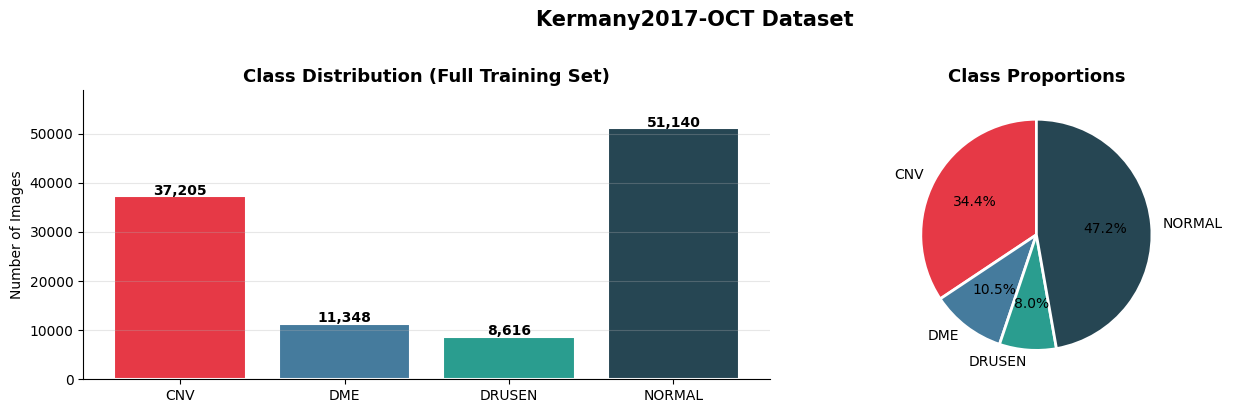


Class counts:
  CNV     : 37,205
  DME     : 11,348
  DRUSEN  : 8,616
  NORMAL  : 51,140


In [ ]:
# ── Class distribution in full training set ───────────────────────────
train_labels = raw_ds["train"]["label"]
unique, counts = np.unique(train_labels, return_counts=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart
colors = ['#E63946', '#457B9D', '#2A9D8F', '#264653']
axes[0].bar(CFG["class_names"], counts, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title("Class Distribution (Full Training Set)", fontsize=13, fontweight='bold')
axes[0].set_ylabel("Number of Images")
for i, (cls, cnt) in enumerate(zip(CFG["class_names"], counts)):
    axes[0].text(i, cnt + 300, f"{cnt:,}", ha='center', fontsize=10, fontweight='bold')
axes[0].set_ylim(0, max(counts) * 1.15)
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Pie chart
axes[1].pie(counts, labels=CFG["class_names"], colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title("Class Proportions", fontsize=13, fontweight='bold')

plt.suptitle("Kermany2017-OCT Dataset", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nClass counts:")
for cls, cnt in zip(CFG["class_names"], counts):
    print(f"  {cls:8s}: {cnt:,}")

Sample OCT B-scans from each class:


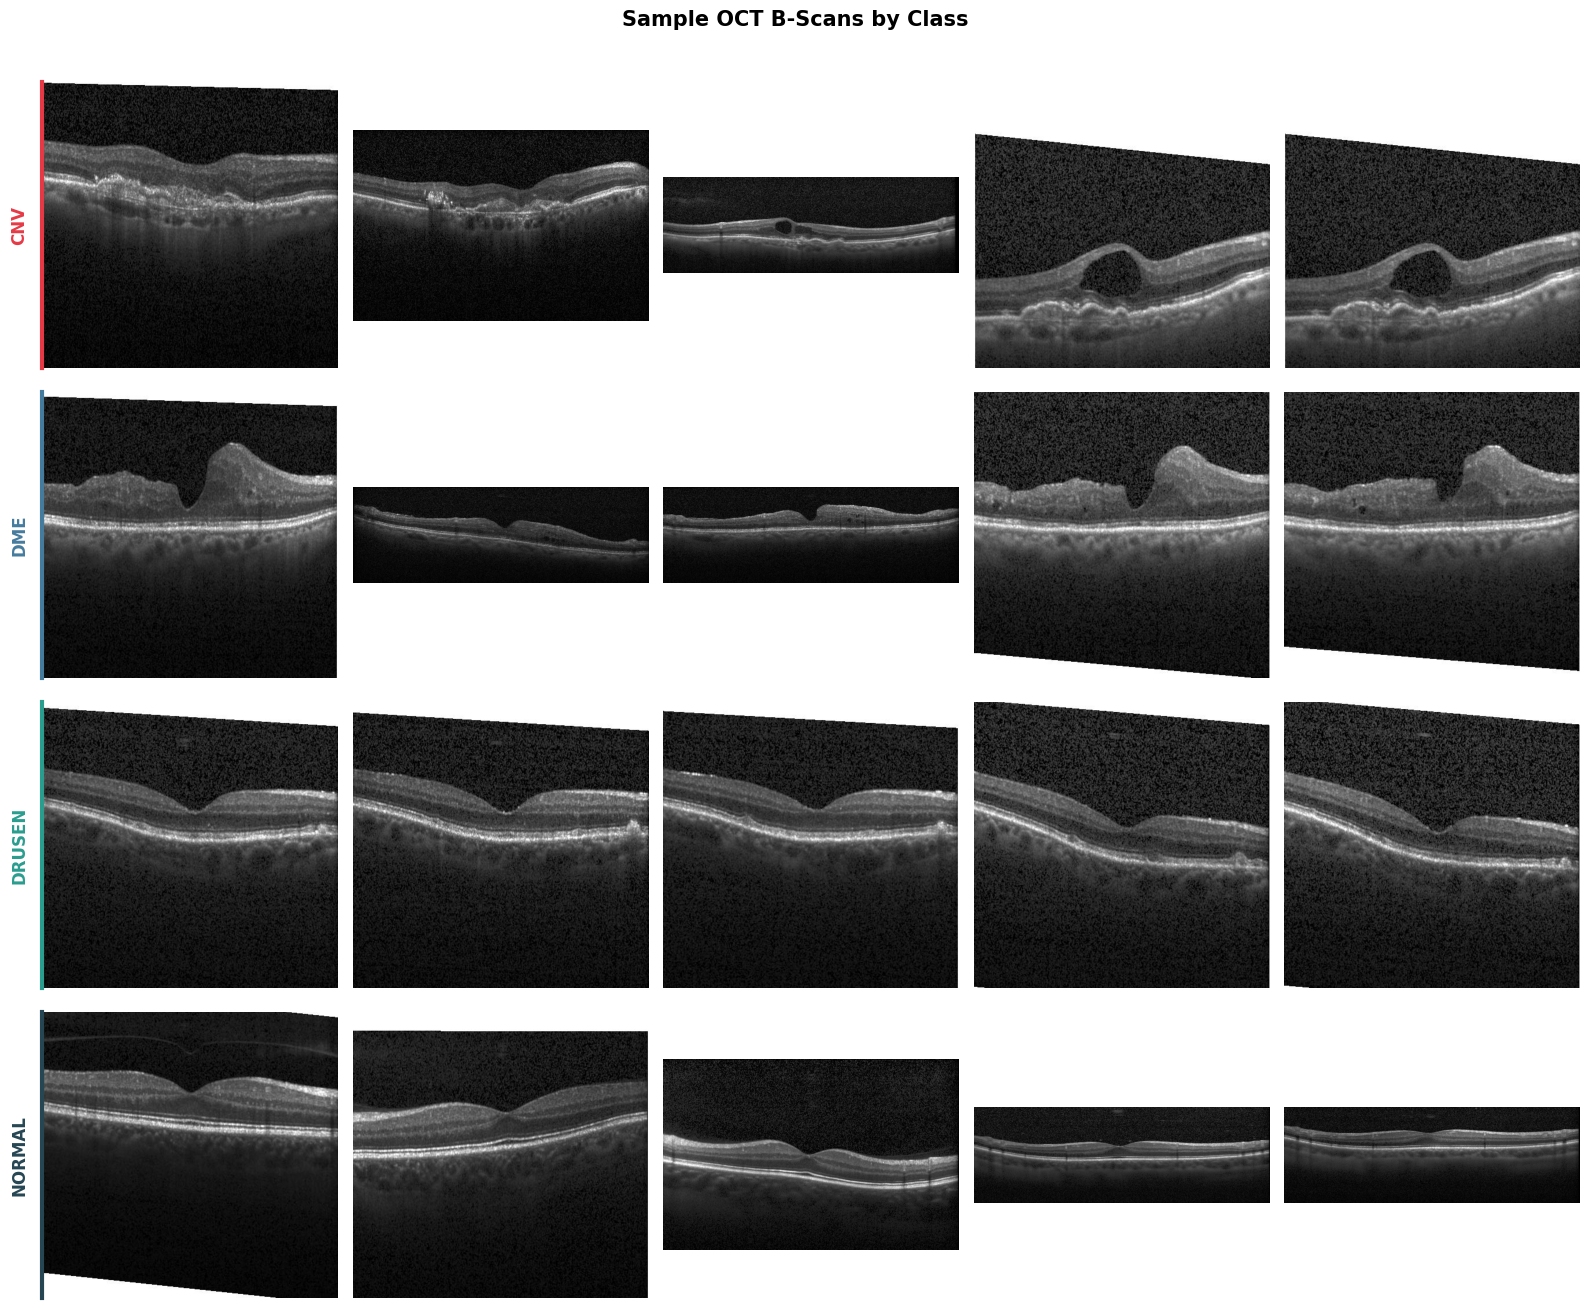


Clinical features visible in OCT B-scans:
  CNV    → subretinal hyperreflective material, fluid beneath RPE
  DME    → intraretinal cystic spaces (dark fluid pockets)
  DRUSEN → small hyperreflective bumps along RPE (Bruch's membrane)
  NORMAL → smooth, layered retinal architecture



In [ ]:
# ── Visualize sample images per class ────────────────────────────────
print("Sample OCT B-scans from each class:")

fig, axes = plt.subplots(4, 5, figsize=(16, 13))
fig.suptitle("Sample OCT B-Scans by Class", fontsize=15, fontweight='bold', y=1.01)

for class_idx, (cls_name, color) in enumerate(zip(CFG["class_names"], colors)):
    # Get indices for this class
    cls_indices = [i for i, l in enumerate(train_labels) if l == class_idx][:5]

    for col, idx in enumerate(cls_indices):
        ax = axes[class_idx][col]
        img = raw_ds["train"][idx]["image"].convert("L")  # convert to grayscale
        ax.imshow(img, cmap='gray')
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(cls_name, fontsize=12, fontweight='bold', color=color,
                         rotation=90, labelpad=10)
            ax.yaxis.set_label_position('left')
            ax.set_yticks([])
            ax.axis('on')
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['bottom'].set_visible(False)
            ax.spines['left'].set_color(color)
            ax.spines['left'].set_linewidth(3)
            ax.set_xticks([])

plt.tight_layout()
plt.show()

print("""
Clinical features visible in OCT B-scans:
  CNV    → subretinal hyperreflective material, fluid beneath RPE
  DME    → intraretinal cystic spaces (dark fluid pockets)
  DRUSEN → small hyperreflective bumps along RPE (Bruch's membrane)
  NORMAL → smooth, layered retinal architecture
""")

---
## 3. Preprocessing & DataLoader

### Why ViT requires specific preprocessing

ViT was pretrained on ImageNet with:
- Input size: **224×224 pixels**
- Normalization: **mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]** (maps pixel values to [-1, 1])
- **RGB format** expected — we convert grayscale to 3-channel

For training we add standard augmentation (flip, crop, color jitter) to improve generalization.

In [ ]:
IMG_SIZE = CFG["image_size"]
MEAN = [0.5, 0.5, 0.5]
STD  = [0.5, 0.5, 0.5]

train_transform = T.Compose([
    T.Lambda(lambda img: img.convert("RGB")),   # grayscale → 3-channel
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=10),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),
    T.Normalize(mean=MEAN, std=STD),
])

val_transform = T.Compose([
    T.Lambda(lambda img: img.convert("RGB")),
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=MEAN, std=STD),
])

print("Transforms defined.")
print(f"  Train: Resize({IMG_SIZE}) + HFlip + Rotation(10°) + ColorJitter + Normalize")
print(f"  Val  : Resize({IMG_SIZE}) + Normalize")

Transforms defined.
  Train: Resize(224) + HFlip + Rotation(10°) + ColorJitter + Normalize
  Val  : Resize(224) + Normalize


In [ ]:
from torch.utils.data import Dataset

class OCTDataset(Dataset):
    """Wrapper around HuggingFace dataset split with PyTorch transforms."""

    def __init__(self, hf_split, transform=None):
        self.data      = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        image  = sample["image"]
        label  = sample["label"]
        if self.transform:
            image = self.transform(image)
        return {"pixel_values": image, "labels": torch.tensor(label, dtype=torch.long)}


def balanced_subsample(hf_split, n_per_class, class_names, seed=42):
    """Return a balanced subset with n_per_class samples per class."""
    rng     = random.Random(seed)
    indices = []
    labels  = hf_split["label"]
    for cls_idx in range(len(class_names)):
        cls_indices = [i for i, l in enumerate(labels) if l == cls_idx]
        chosen      = rng.sample(cls_indices, min(n_per_class, len(cls_indices)))
        indices.extend(chosen)
    rng.shuffle(indices)
    return hf_split.select(indices)


# Create subsets
print("Creating balanced subsets...")
train_subset = balanced_subsample(
    raw_ds["train"], CFG["samples_per_class_train"], CFG["class_names"]
)
val_subset = balanced_subsample(
    raw_ds["train"], CFG["samples_per_class_val"], CFG["class_names"], seed=99
)

train_ds = OCTDataset(train_subset, transform=train_transform)
val_ds   = OCTDataset(val_subset,   transform=val_transform)
test_ds  = OCTDataset(raw_ds["test"], transform=val_transform)

train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"], shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=CFG["batch_size"], shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=CFG["batch_size"], shuffle=False, num_workers=2)

print(f"  Train : {len(train_ds):,} images  ({len(train_loader)} batches of {CFG['batch_size']})")
print(f"  Val   : {len(val_ds):,} images")
print(f"  Test  : {len(test_ds):,} images")

Creating balanced subsets...
  Train : 6,000 images  (188 batches of 32)
  Val   : 800 images
  Test  : 1,000 images


Batch verification:
  pixel_values shape : torch.Size([32, 3, 224, 224])
  labels shape       : torch.Size([32])
  pixel value range  : [-1.00, 1.00]
  label distribution : {'CNV': 10, 'DME': 10, 'DRUSEN': 5, 'NORMAL': 7}


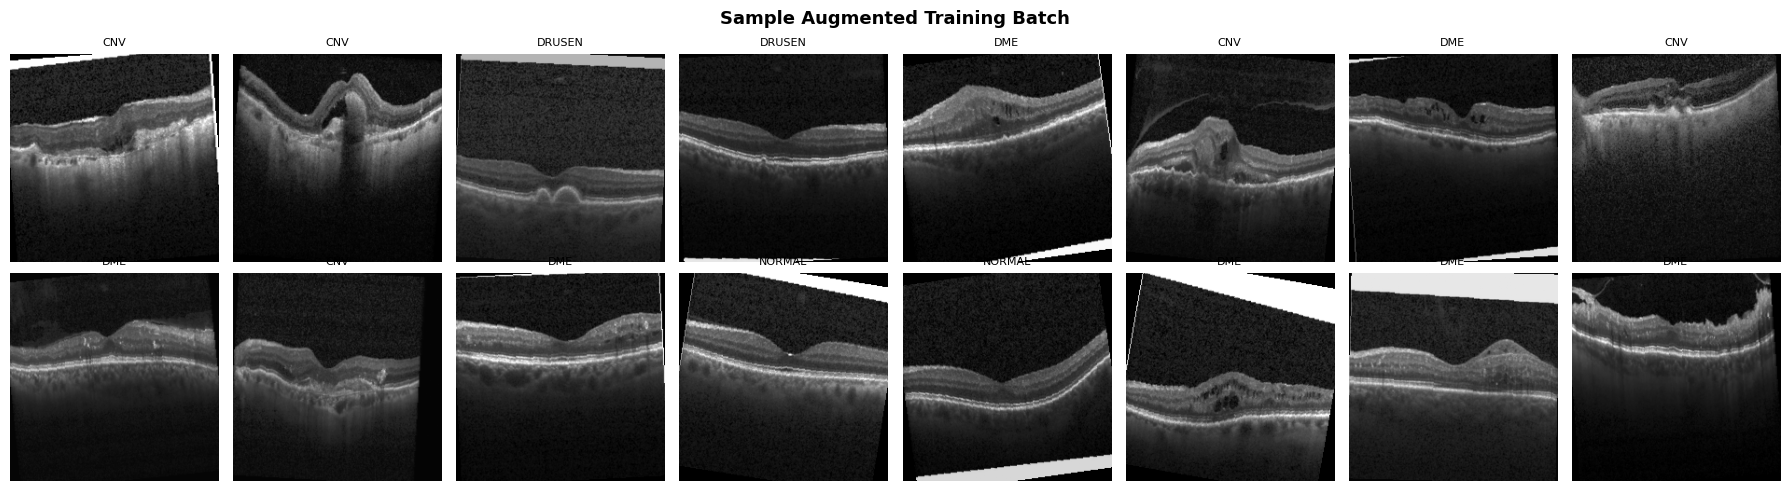

In [ ]:
# Verify a batch
batch = next(iter(train_loader))
print("Batch verification:")
print(f"  pixel_values shape : {batch['pixel_values'].shape}")
print(f"  labels shape       : {batch['labels'].shape}")
print(f"  pixel value range  : [{batch['pixel_values'].min():.2f}, {batch['pixel_values'].max():.2f}]")
print(f"  label distribution : { {CFG['class_names'][l]: (batch['labels']==l).sum().item() for l in range(4)} }")

# Visualize augmented batch
def denormalize(tensor):
    return (tensor * 0.5 + 0.5).clamp(0, 1)

fig, axes = plt.subplots(2, 8, figsize=(18, 5))
fig.suptitle("Sample Augmented Training Batch", fontsize=13, fontweight='bold')
for i, ax in enumerate(axes.flat):
    if i < len(batch['pixel_values']):
        img = denormalize(batch['pixel_values'][i]).permute(1, 2, 0).numpy()
        ax.imshow(img)
        ax.set_title(CFG['class_names'][batch['labels'][i].item()], fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

---
## 4. Model Setup: Fine-tuning ViT

### How Vision Transformer (ViT) Works

```
Input Image (224×224)
        ↓
Patch Embedding  → 196 patches of 16×16 pixels
        ↓
[CLS] token + Position Embeddings
        ↓
12× Transformer Encoder Blocks (Multi-Head Self-Attention + MLP)
        ↓
[CLS] token output  →  Classification Head  →  4-class softmax
```

Key innovation: ViT treats an image as a **sequence of patches**, applying the same self-attention mechanism originally designed for NLP. Each patch can attend to every other patch globally — unlike CNNs which are limited by their receptive field.

### Fine-tuning Strategy

We use **full fine-tuning** (all layers trainable) but with a small learning rate to preserve pretrained representations:
- The 12 transformer encoder blocks learn domain-specific retinal features
- The final classification head (randomly initialized) learns the 4-class mapping

In [ ]:
print(f"Loading pretrained ViT: {CFG['model_name']}")

model = ViTForImageClassification.from_pretrained(
    CFG["model_name"],
    num_labels=CFG["num_classes"],
    id2label={i: name for i, name in enumerate(CFG["class_names"])},
    label2id={name: i for i, name in enumerate(CFG["class_names"])},
    ignore_mismatched_sizes=True,   # classifier head will be replaced
)
model = model.to(DEVICE)

# Count parameters
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nModel: ViT-Base/16")
print(f"  Total parameters     : {total_params:,}")
print(f"  Trainable parameters : {trainable_params:,}")
print(f"  Architecture         : 12 transformer blocks, 768 hidden dim, 12 attention heads")
print(f"  Classification head  : Linear(768 → {CFG['num_classes']}) [randomly initialized]")

Loading pretrained ViT: google/vit-base-patch16-224


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([4])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([4, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.



Model: ViT-Base/16
  Total parameters     : 85,801,732
  Trainable parameters : 85,801,732
  Architecture         : 12 transformer blocks, 768 hidden dim, 12 attention heads
  Classification head  : Linear(768 → 4) [randomly initialized]


In [ ]:
# ── Load from checkpoint if available (skip training) ────────────────
from google.colab import drive
drive.mount('/content/drive')

SAVE_PATH            = "/content/drive/MyDrive/vit_oct_checkpoint"
LOAD_FROM_CHECKPOINT = False  # ← change to True after first successful training run

if LOAD_FROM_CHECKPOINT and os.path.exists(SAVE_PATH):
    model = ViTForImageClassification.from_pretrained(
        SAVE_PATH,
        num_labels        = CFG["num_classes"],
        id2label          = {i: name for i, name in enumerate(CFG["class_names"])},
        label2id          = {name: i for i, name in enumerate(CFG["class_names"])},
    ).to(DEVICE)
    print("✅ Loaded from checkpoint — skipping training")
else:
    print("🔁 No checkpoint loaded — proceeding to train from scratch")

Mounted at /content/drive
🔁 No checkpoint loaded — proceeding to train from scratch


---
## 5. Training

We use HuggingFace `Trainer` for a clean, reproducible training loop. It handles:
- Mixed precision (FP16) automatically
- Learning rate scheduling with warmup
- Evaluation after each epoch
- Best model checkpointing

**Estimated training time on Colab T4:** ~15–20 minutes for 5 epochs

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1  = f1_score(labels, predictions, average='macro')
    return {
        "accuracy" : round(acc, 4),
        "macro_f1" : round(f1, 4),
    }

In [ ]:
training_args = TrainingArguments(
    output_dir                  = CFG["output_dir"],
    num_train_epochs            = CFG["epochs"],
    per_device_train_batch_size = CFG["batch_size"],
    per_device_eval_batch_size  = CFG["batch_size"],
    learning_rate               = CFG["learning_rate"],
    weight_decay                = CFG["weight_decay"],
    warmup_ratio                = CFG["warmup_ratio"],
    lr_scheduler_type           = "cosine",
    eval_strategy               = "epoch",   # renamed from evaluation_strategy
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "macro_f1",
    fp16                        = torch.cuda.is_available(),
    dataloader_num_workers      = 2,
    logging_steps               = 50,
    report_to                   = "none",
    seed                        = CFG["seed"],
)

print("Training configuration:")
print(f"  Epochs        : {CFG['epochs']}")
print(f"  Batch size    : {CFG['batch_size']}")
print(f"  Learning rate : {CFG['learning_rate']}")
print(f"  LR Schedule   : Cosine decay with {CFG['warmup_ratio']*100:.0f}% warmup")
print(f"  Mixed FP16    : {torch.cuda.is_available()}")
print(f"  Best model    : saved by macro_f1")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training configuration:
  Epochs        : 5
  Batch size    : 32
  Learning rate : 0.0002
  LR Schedule   : Cosine decay with 10% warmup
  Mixed FP16    : True
  Best model    : saved by macro_f1


In [ ]:
# Custom data collator for HuggingFace Trainer compatibility
def collate_fn(batch):
    pixel_values = torch.stack([item["pixel_values"] for item in batch])
    labels       = torch.tensor([item["labels"] for item in batch])
    return {"pixel_values": pixel_values, "labels": labels}

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_ds,
    eval_dataset    = val_ds,
    compute_metrics = compute_metrics,
    data_collator   = collate_fn,
)

In [ ]:
print("Starting training...")
print("="*60)
train_result = trainer.train()
print("="*60)
print("Training complete!")
print(f"  Total steps      : {train_result.global_step}")
print(f"  Final train loss : {train_result.training_loss:.4f}")

Starting training...


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.400022,0.328119,0.881200,0.881700
2,0.260664,0.311368,0.892500,0.893300
3,0.237632,0.249205,0.922500,0.922100
4,0.148982,0.258438,0.913700,0.913800
5,0.104898,0.242441,0.920000,0.919600


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training complete!
  Total steps      : 940
  Final train loss : 0.2654


In [ ]:
# ── Save checkpoint after training ───────────────────────────────────
if not LOAD_FROM_CHECKPOINT:
    model.save_pretrained(SAVE_PATH)
    print(f"✅ Model saved to {SAVE_PATH}")
else:
    print("⏭️  Checkpoint load was used — save skipped")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model saved to /content/drive/MyDrive/vit_oct_checkpoint


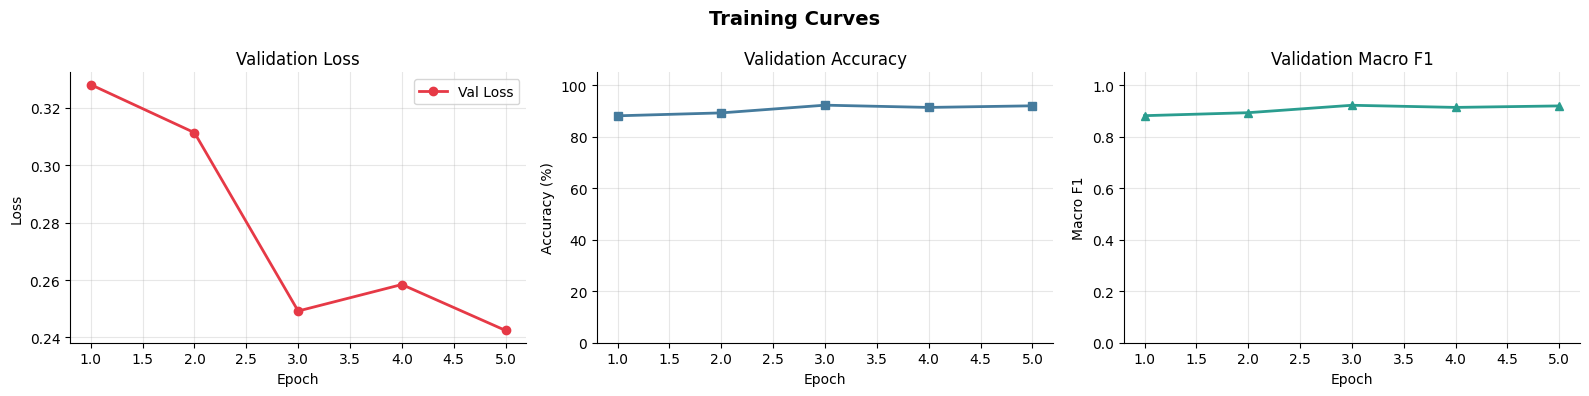

In [38]:
# ── Plot training curves ──────────────────────────────────────────────
log_history = trainer.state.log_history

# Extract epoch-level metrics
train_losses, eval_losses, eval_accs, eval_f1s, epochs_logged = [], [], [], [], []

step_train_loss = {}
for entry in log_history:
    if "loss" in entry and "eval_loss" not in entry:
        step_train_loss[entry.get("epoch", 0)] = entry["loss"]
    if "eval_loss" in entry:
        eval_losses.append(entry["eval_loss"])
        eval_accs.append(entry.get("eval_accuracy", 0))
        eval_f1s.append(entry.get("eval_macro_f1", 0))
        epochs_logged.append(entry["epoch"])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Training Curves", fontsize=14, fontweight='bold')

# Loss
axes[0].plot(epochs_logged, eval_losses, 'o-', color='#E63946', linewidth=2, label='Val Loss')
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Validation Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(epochs_logged, [a*100 for a in eval_accs], 's-', color='#457B9D', linewidth=2)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Validation Accuracy")
axes[1].set_ylim(0, 105); axes[1].grid(alpha=0.3)

# Macro F1 Max Verstappen from Red Bull then Alex Albon from Williams then
axes[2].plot(epochs_logged, eval_f1s, '^-', color='#2A9D8F', linewidth=2)
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Macro F1")
axes[2].set_title("Validation Macro F1")
axes[2].set_ylim(0, 1.05); axes[2].grid(alpha=0.3)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

---
## 6. Evaluation

We evaluate the best checkpoint on the **held-out test set** (1,000 images) using:

| Metric | Why it matters |
|--------|---------------|
| **Accuracy** | Overall correctness |
| **Macro F1** | Balanced performance across all 4 classes |
| **Macro AUROC** | Discrimination ability regardless of threshold |
| **Confusion Matrix** | Reveals which classes are confused with each other |

In [ ]:
print("Running evaluation on test set...")
model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for batch in test_loader:
        pixel_values = batch["pixel_values"].to(DEVICE)
        labels       = batch["labels"]

        outputs = model(pixel_values=pixel_values)
        probs   = torch.softmax(outputs.logits, dim=-1).cpu().numpy()
        preds   = np.argmax(probs, axis=-1)

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
        all_probs.extend(probs)

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

# Compute metrics
acc    = accuracy_score(all_labels, all_preds)
macro_f1  = f1_score(all_labels, all_preds, average='macro')
labels_bin = label_binarize(all_labels, classes=list(range(CFG["num_classes"])))
auroc  = roc_auc_score(labels_bin, all_probs, multi_class='ovr', average='macro')

print("\n" + "="*50)
print("  TEST SET RESULTS")
print("="*50)
print(f"  Accuracy   : {acc:.4f} ({acc*100:.2f}%)")
print(f"  Macro F1   : {macro_f1:.4f}")
print(f"  Macro AUROC: {auroc:.4f}")
print("="*50)
print("\nPer-class report:")
print(classification_report(all_labels, all_preds, target_names=CFG["class_names"]))

Running evaluation on test set...

  TEST SET RESULTS
  Accuracy   : 0.9510 (95.10%)
  Macro F1   : 0.9508
  Macro AUROC: 0.9951

Per-class report:
              precision    recall  f1-score   support

         CNV       0.88      1.00      0.93       250
         DME       0.97      1.00      0.98       250
      DRUSEN       0.97      0.86      0.91       250
      NORMAL       1.00      0.95      0.97       250

    accuracy                           0.95      1000
   macro avg       0.95      0.95      0.95      1000
weighted avg       0.95      0.95      0.95      1000



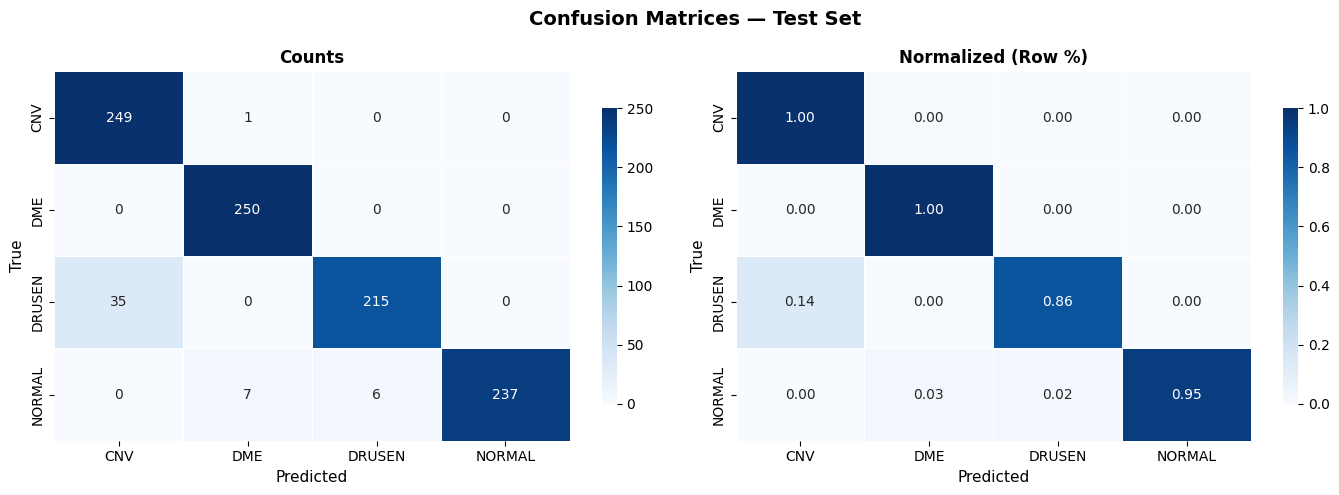

In [ ]:
# ── Confusion Matrix ──────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # row-normalize

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Confusion Matrices — Test Set", fontsize=14, fontweight='bold')

for ax, data, fmt, title in zip(
    axes,
    [cm, cm_norm],
    ['d', '.2f'],
    ["Counts", "Normalized (Row %)"],
):
    sns.heatmap(
        data, annot=True, fmt=fmt, ax=ax,
        xticklabels=CFG["class_names"],
        yticklabels=CFG["class_names"],
        cmap="Blues", linewidths=0.5, linecolor='white',
        cbar_kws={'shrink': 0.8}
    )
    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("True", fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

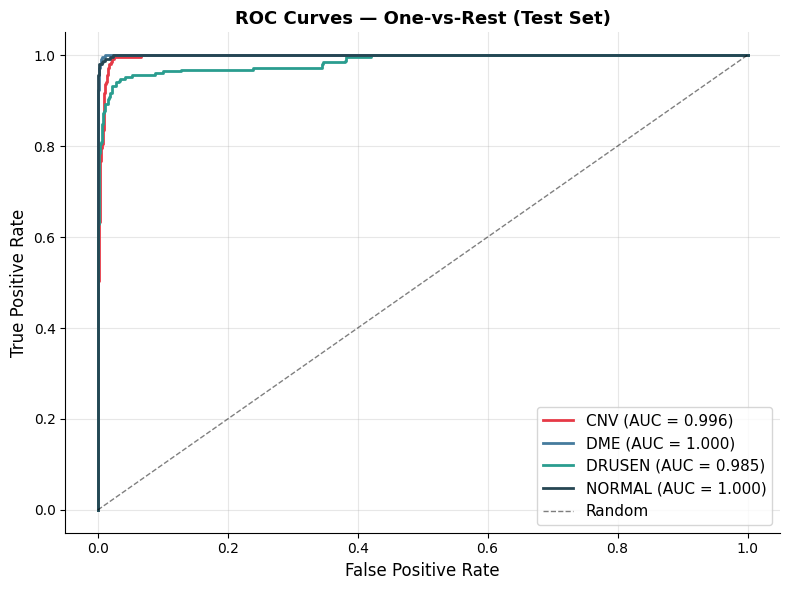

In [ ]:
# ── ROC Curves (one-vs-rest) ──────────────────────────────────────────
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(8, 6))

for cls_idx, (cls_name, color) in enumerate(zip(CFG["class_names"], colors)):
    fpr, tpr, _ = roc_curve(labels_bin[:, cls_idx], all_probs[:, cls_idx])
    cls_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f"{cls_name} (AUC = {cls_auc:.3f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random')
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curves — One-vs-Rest (Test Set)", fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

---
## 7. Explainability: Grad-CAM vs Attention Rollout

### Why Explainability Matters in Medical AI

A model that achieves 95% accuracy is clinically useful only if clinicians can trust *why* it makes decisions. Explainability methods produce heatmaps showing which image regions drove the prediction — validating that the model attends to genuine pathological anatomy rather than spurious artifacts.

### Why We Compare Two Methods

During development, Grad-CAM was first applied but showed limitations specific to transformer architectures:

| Method | Mechanism | Designed for | Limitation on ViT |
|--------|-----------|-------------|-------------------|
| **Grad-CAM** | Gradient of class score w.r.t. feature maps | CNNs | By layer 11, ViT's global attention dissolves spatial locality — gradients reflect high-contrast edges (background, choroid boundary) rather than subtle pathological tissue |
| **Attention Rollout** | Traces [CLS] token attention through all 12 layers | Transformers | Aggregates global context — natively aligned with how ViT builds its classification decision |

### How Attention Rollout Works
```
Input patches (196 × 16×16)
        ↓
Layer 1 attention matrix [197 × 197]  ← which patches attend to which
        ↓  multiply through all 12 layers (with residual)
Layer 12 attention matrix
        ↓
CLS token row → 196 patch importance scores
        ↓
Reshape to 14×14 → upsample to 224×224 → overlay on image
```

The CLS token is the patch that aggregates information for the final classification decision. Tracing what it attended to directly reveals the model's evidence.

### Expected Clinical Activation Regions

| Class | Pathological anatomy | Expected heatmap focus |
|-------|---------------------|----------------------|
| **CNV** | Subretinal/sub-RPE hyperreflective tissue | Elevation in outer retina / sub-RPE space |
| **DME** | Intraretinal cystic fluid spaces | Dark cystic pockets within retinal layers |
| **DRUSEN** | Focal RPE elevations at Bruch's membrane | Irregular bumps along the RPE line |
| **NORMAL** | No pathology | Diffuse spread — no focal hotspot |

In [34]:
# ── Explainability Setup: Grad-CAM + Attention Rollout ───────────────
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import transformers

class ViTGradCAMWrapper(nn.Module):
    def __init__(self, vit_model):
        super().__init__()
        self.model = vit_model
    def forward(self, x):
        return self.model(pixel_values=x).logits

wrapped_model = ViTGradCAMWrapper(model).to(DEVICE)
wrapped_model.eval()

def vit_reshape_transform(tensor, height=14, width=14):
    result = tensor[:, 1:, :]
    result = result.reshape(tensor.size(0), height, width, tensor.size(2))
    result = result.permute(0, 3, 1, 2).contiguous()
    return result

# Build attn_model ONCE — suppress the expected MISMATCH warning
transformers.logging.set_verbosity_error()
attn_model = ViTForImageClassification.from_pretrained(
    CFG["model_name"],
    num_labels              = CFG["num_classes"],
    id2label                = {i: name for i, name in enumerate(CFG["class_names"])},
    label2id                = {name: i for i, name in enumerate(CFG["class_names"])},
    ignore_mismatched_sizes = True,
    attn_implementation     = "eager",
)
attn_model.load_state_dict(model.state_dict())
attn_model = attn_model.to(DEVICE).eval()
transformers.logging.set_verbosity_warning()

def get_attention_rollout(input_tensor):
    """Attention Rollout — ViT-native explainability, no gradients needed."""
    with torch.no_grad():
        outputs = attn_model(pixel_values=input_tensor, output_attentions=True)

    attn_mat = torch.stack([a.squeeze(0).mean(dim=0) for a in outputs.attentions])
    residual = torch.eye(attn_mat.size(-1), device=attn_mat.device)
    attn_mat = (attn_mat + residual)
    attn_mat = attn_mat / attn_mat.sum(dim=-1, keepdim=True)

    rollout = attn_mat[0]
    for i in range(1, attn_mat.size(0)):
        rollout = torch.matmul(attn_mat[i], rollout)

    cls_attn = rollout[0, 1:].reshape(14, 14)
    cls_attn = (cls_attn - cls_attn.min()) / (cls_attn.max() - cls_attn.min() + 1e-8)
    heatmap  = torch.nn.functional.interpolate(
        cls_attn.unsqueeze(0).unsqueeze(0), size=(224, 224),
        mode='bilinear', align_corners=False
    )
    return heatmap.squeeze().cpu().numpy()


def get_cam(input_tensor, target_class):
    """Grad-CAM — gradient-based, kept for comparison."""
    target_layer = wrapped_model.model.vit.encoder.layer[11].layernorm_before
    with GradCAM(model=wrapped_model, target_layers=[target_layer],
                 reshape_transform=vit_reshape_transform) as cam_obj:
        with torch.enable_grad():
            grayscale = cam_obj(input_tensor=input_tensor,
                                targets=[ClassifierOutputTarget(target_class)])[0]
    return grayscale

print("✅ Attention Rollout + Grad-CAM ready")
print("   Primary : Attention Rollout (ViT-native, no gradients)")
print("   Fallback : Grad-CAM (gradient-based, for comparison)")

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

✅ Attention Rollout + Grad-CAM ready
   Primary : Attention Rollout (ViT-native, no gradients)
   Fallback : Grad-CAM (gradient-based, for comparison)


In [36]:
def visualize_explainability(dataset, class_names, n_per_class=2, seed=42):
    """Original | Grad-CAM | Attention Rollout — with disease labels and predictions."""
    random.seed(seed)

    class_examples = {i: [] for i in range(len(class_names))}
    for idx in random.sample(range(len(dataset)), min(500, len(dataset))):
        sample = dataset[idx]
        label  = sample["labels"].item()
        if len(class_examples[label]) < n_per_class:
            class_examples[label].append((sample["pixel_values"], label, idx))
        if all(len(v) == n_per_class for v in class_examples.values()):
            break

    n_cols = n_per_class * 3
    fig, axes = plt.subplots(
        len(class_names), n_cols,
        figsize=(n_cols * 3.2, len(class_names) * 3.2)
    )
    fig.suptitle(
        "Explainability: Grad-CAM vs Attention Rollout\n"
        "Each group — Original | Grad-CAM | Attn Rollout",
        fontsize=13, fontweight='bold', y=1.01
    )

    # Column headers
    col_labels = (["Original", "Grad-CAM", "Attn Rollout"] * n_per_class)
    col_colors = {'Original': 'black', 'Grad-CAM': '#E63946', 'Attn Rollout': '#2A9D8F'}
    for col, lbl in enumerate(col_labels):
        axes[0][col].set_title(lbl, fontsize=9, fontweight='bold', color=col_colors[lbl])

    # Clinical notes per class
    clinical_note = {
        0: "CNV — subretinal tissue / sub-RPE elevation",
        1: "DME — intraretinal cystic fluid pockets",
        2: "DRUSEN — RPE/Bruch's membrane bumps",
        3: "NORMAL — smooth layered retina, no focal pathology",
    }

    for row, cls_idx in enumerate(range(len(class_names))):
        for ex_idx, (pixel_vals, _, __) in enumerate(class_examples[cls_idx]):
            img_np       = denormalize(pixel_vals).permute(1, 2, 0).numpy().astype(np.float32)
            input_tensor = pixel_vals.unsqueeze(0).to(DEVICE)
            base_col     = ex_idx * 3

            # Get model prediction + confidence
            with torch.no_grad():
                probs = torch.softmax(model(pixel_values=input_tensor).logits, dim=-1)[0].cpu().numpy()
            pred       = int(np.argmax(probs))
            confidence = probs[pred] * 100
            correct    = "right" if pred == cls_idx else "wrong"

            # ── Original ──
            ax = axes[row][base_col]
            ax.imshow(img_np)
            ax.axis('off')
            # Row label on first example only
            if ex_idx == 0:
                ax.set_ylabel(
                    f"{class_names[cls_idx]}\n{clinical_note[cls_idx]}",
                    fontsize=7.5, fontweight='bold',
                    color=colors[cls_idx], labelpad=6
                )
            # Prediction subtitle under original
            ax.set_title(
                f"{correct} Pred: {class_names[pred]} ({confidence:.0f}%)",
                fontsize=7, color='green' if pred == cls_idx else 'red'
            )

            # ── Grad-CAM ──
            gc = get_cam(input_tensor, cls_idx)
            axes[row][base_col + 1].imshow(show_cam_on_image(img_np, gc, use_rgb=True))
            axes[row][base_col + 1].axis('off')

            # ── Attention Rollout ──
            rollout = get_attention_rollout(input_tensor)
            axes[row][base_col + 2].imshow(show_cam_on_image(img_np, rollout, use_rgb=True))
            axes[row][base_col + 2].axis('off')

    plt.tight_layout()
    plt.show()

print("Generating Grad-CAM vs Attention Rollout comparison...")
visualize_explainability(test_ds, CFG["class_names"], n_per_class=2)

Output hidden; open in https://colab.research.google.com to view.

In [37]:
# ── Final Summary ─────────────────────────────────────────────────────
print("="*60)
print("  EXPERIMENT SUMMARY")
print("="*60)
print(f"  Model       : ViT-Base/16 (fine-tuned)")
print(f"  Dataset     : Kermany2017-OCT (4 classes)")
print(f"  Train size  : {len(train_ds):,} images")
print(f"  Test size   : {len(test_ds):,} images")
print(f"  Epochs      : {CFG['epochs']}")
print("-"*60)
print(f"  Accuracy    : {acc*100:.2f}%")
print(f"  Macro F1    : {macro_f1:.4f}")
print(f"  Macro AUROC : {auroc:.4f}")
print("="*60)

  EXPERIMENT SUMMARY
  Model       : ViT-Base/16 (fine-tuned)
  Dataset     : Kermany2017-OCT (4 classes)
  Train size  : 6,000 images
  Test size   : 1,000 images
  Epochs      : 5
------------------------------------------------------------
  Accuracy    : 95.10%
  Macro F1    : 0.9508
  Macro AUROC : 0.9951


---
## 8. Discussion & Clinical Interpretation

### Summary of Results

| Metric | Value |
|--------|-------|
| Test Accuracy | **95.10%** |
| Macro F1 | **0.9508** |
| Macro AUROC | **0.9951** |
| Weakest class | DRUSEN (recall 0.86, 14% confused with CNV) |

### Explainability Findings

Comparing Grad-CAM and Attention Rollout on the same images revealed a clear methodological difference:

**Grad-CAM** produced diffuse activations biased toward high-contrast image boundaries — the black background corner in CNV images and the bright choroid band in DRUSEN/NORMAL — rather than the pathological tissue itself. This is a known failure mode when applying CNN-designed gradient attribution to transformers, where spatial locality dissolves by the final encoder layer.

**Attention Rollout** produced more anatomically plausible maps:

| Class | Observed activation | Clinical alignment |
|-------|--------------------|--------------------|
| **CNV** | Concentrated around subretinal elevation and outer retinal disruption | ✅ Correct zone — sub-RPE tissue |
| **DME** | Focal activation on macular dome; tightest on images with visible cysts | ✅ Correct — macular edema region |
| **DRUSEN** | Band activation along RPE interface, surrounding deposit boundaries | ✅ Correct layer — Bruch's membrane interface |
| **NORMAL** | Diffuse spread along foveal region with no dominant hotspot | ✅ Appropriate — absence of focal pathology |

### Why DRUSEN→CNV Confusion Is Clinically Expected

The confusion matrix shows 35/250 DRUSEN cases misclassified as CNV. Both pathologies involve **sub-RPE changes along Bruch's membrane** — the same anatomical layer. Early CNV can present with drusen-like morphology, and intermediate drusen can develop into CNV. This boundary is ambiguous even for experienced graders.

### Limitations

1. **Explainability method mismatch:** Grad-CAM is not natively suited for ViT, while Attention Rollout provides more faithful localization but still averages attention heads, which may dilute class-specific signals
2. **Subsampling:** Training used 6,000 of 108,000 available images — full dataset training would likely improve DRUSEN recall
3. **Balanced test set:** The 1,000-image test set is artificially balanced (250/class); the real dataset has severe class imbalance (NORMAL: 47%, DRUSEN: 8%) — real-world performance may differ
4. **Single scanner:** All images from one acquisition protocol — generalization to other OCT devices (e.g., Heidelberg Spectralis) requires domain adaptation validation
